# Анализ нарешанности учеников по компетенциям

Собираем простые признаки по каждому ученику и компетенции: сколько заданий с этой компетенцией ученик решал, сколько решил правильно, долю правильных решений и время между первым и последним решением компетенции.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

In [ ]:
task_map = pd.read_csv('task_competence_mapping.csv', sep=';', encoding='utf-8-sig')
task_sub = pd.read_csv('user_task_submissions.csv', sep=';', encoding='utf-8-sig')
practice = pd.read_csv('user_practice_submissions.csv', sep=';', encoding='utf-8-sig')

print('task_map:', task_map.shape)
print('task_sub:', task_sub.shape)
print('practice:', practice.shape)

task_map: (1598, 10)
task_sub: (3143, 16)
practice: (363, 11)


In [ ]:
task_sub['submission_time'] = pd.to_datetime(task_sub['submission_time'], errors='coerce', utc=True)

if task_sub['is_correct'].dtype == 'object':
    task_sub['is_correct'] = (
        task_sub['is_correct']
        .astype(str)
        .str.lower()
        .map({'true': True, 'false': False, '1': True, '0': False})
    )

task_sub['is_correct_int'] = task_sub['is_correct'].fillna(False).astype(int)

In [ ]:
task_map_small = task_map[[
    'task_id',
    'competence_id',
    'competence_code',
    'competence_name'
]].drop_duplicates()

sub_comp = task_sub.merge(
    task_map_small,
    on='task_id',
    how='left'
)

print('Всего строк решений:', len(task_sub))
print('Строк после join:', len(sub_comp))
print('Строк без компетенции:', sub_comp['competence_id'].isna().sum())

sub_comp_known = sub_comp.dropna(subset=['competence_id']).copy()

Всего строк решений: 3143
Строк после join: 8300
Строк без компетенции: 564


In [ ]:
readiness = (
    sub_comp_known
    .groupby([
        'user_number',
        'competence_id',
        'competence_code',
        'competence_name'
    ], as_index=False)
    .agg(
        solved_tasks_count=('submission_id', 'nunique'),
        correct_solved_tasks_count=('is_correct_int', 'sum'),
        first_solve_time=('submission_time', 'min'),
        last_solve_time=('submission_time', 'max')
    )
)

readiness['accuracy'] = (
    readiness['correct_solved_tasks_count'] / readiness['solved_tasks_count']
)

readiness['days_from_first_to_last'] = (
    readiness['last_solve_time'] - readiness['first_solve_time']
).dt.total_seconds() / 86400

readiness = readiness.sort_values(
    ['user_number', 'solved_tasks_count'],
    ascending=[True, False]
)

print('Итоговая таблица:', readiness.shape)
display(readiness.head(20))

Итоговая таблица: (1264, 10)


,user_number,competence_id,competence_code,competence_name,solved_tasks_count,correct_solved_tasks_count,first_solve_time,last_solve_time,accuracy,days_from_first_to_last
14,1,6a379d79-219c-4c02-a18a-fc4d5439e209,1.0.0. Планиметрия,Планиметрия,21,19,2026-03-16 18:15:51.580308+00:00,2026-03-22 09:40:01.786033+00:00,0.904762,5.641785
29,1,e0bf6fb3-c7cf-47af-8f34-aa79a7837321,10.0.0,Текстовые задачи,20,20,2026-02-25 17:41:51.998349+00:00,2026-03-16 18:15:51.580308+00:00,1.000000,19.023606
0,1,078423e2-9dcd-4e8e-9887-702ee08b0153,6.2.2,Умеет приводить подобные слагаемые и упрощать выражения,6,6,2026-03-15 18:13:52.861923+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.009457
19,1,8ce2c2e8-77c7-434a-b156-23485e7449f1,6.1.4,"""Умеет решать линейное уравнение вида k*x =a""",5,5,2026-03-15 18:13:52.861923+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.009457
3,1,2e7f87eb-5a14-4b20-99f4-7efc507e829b,4.1.4,"Умеет вычислять значение отношения двух чисел, заданного в виде дроби a/b, как результата деления a на b",4,4,2026-03-15 17:47:23.041889+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.027857
12,1,5cf7d4dd-1c3f-4fb7-821c-6d4aa6df09aa,5.0.0,Сложные задачи по теории вероятностей,4,4,2026-03-15 17:47:23.041889+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.027857
18,1,8bec0745-c4fb-44d5-b059-7b7b84563b02,4.1.1,Умеет определять число всех равновозможных исходов n по условию задачи,4,4,2026-03-15 17:47:23.041889+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.027857
24,1,b8044d8a-9b87-4042-9eaa-b3e139bf6278,4.1.3,Умеет вычислять вероятность события по формуле классической вероятности P = m/n при равновозможных исходах,4,4,2026-03-15 17:47:23.041889+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.027857
9,1,4462b5b1-2d3d-422b-970a-c9d696d46a4c,9.1.3.,Умеет подставлять известные значения (числа или выражения) в заданную формулу для получения уравнения/выражения отно...,3,3,2026-03-15 18:13:52.861923+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.009457
10,1,5067001a-a115-4624-823b-4de68176f569,4.1.2,Умеет определять число благоприятных исходов m по условию задачи,3,3,2026-03-15 18:13:52.861923+00:00,2026-03-16 18:27:29.926178+00:00,1.000000,1.009457


In [ ]:
readiness.to_csv('student_competence_readiness.csv', index=False, encoding='utf-8-sig')

print('Saved: student_competence_readiness.csv')

Saved: student_competence_readiness.csv


In [ ]:
competence_summary = (
    sub_comp_known
    .groupby(['competence_id', 'competence_code', 'competence_name'], as_index=False)
    .agg(
        solved_tasks_count=('submission_id', 'nunique'),
        correct_solved_tasks_count=('is_correct_int', 'sum'),
        students_count=('user_number', 'nunique')
    )
)

competence_summary['accuracy'] = (
    competence_summary['correct_solved_tasks_count'] / competence_summary['solved_tasks_count']
)

competence_summary = competence_summary.sort_values('solved_tasks_count', ascending=False)

display(competence_summary.head(15))

,competence_id,competence_code,competence_name,solved_tasks_count,correct_solved_tasks_count,students_count,accuracy
2,078423e2-9dcd-4e8e-9887-702ee08b0153,6.2.2,Умеет приводить подобные слагаемые и упрощать выражения,575,498,28,0.866087
63,8ce2c2e8-77c7-434a-b156-23485e7449f1,6.1.4,"""Умеет решать линейное уравнение вида k*x =a""",414,366,26,0.884058
21,2e7f87eb-5a14-4b20-99f4-7efc507e829b,4.1.4,"Умеет вычислять значение отношения двух чисел, заданного в виде дроби a/b, как результата деления a на b",278,246,29,0.884892
75,b8044d8a-9b87-4042-9eaa-b3e139bf6278,4.1.3,Умеет вычислять вероятность события по формуле классической вероятности P = m/n при равновозможных исходах,278,246,29,0.884892
42,6a379d79-219c-4c02-a18a-fc4d5439e209,1.0.0. Планиметрия,Планиметрия,270,192,34,0.711111
62,8bec0745-c4fb-44d5-b059-7b7b84563b02,4.1.1,Умеет определять число всех равновозможных исходов n по условию задачи,266,237,29,0.890977
8,10a8e01b-d429-47d1-a81f-d71dcf486c7e,3.0.0. Стереометрия,Стереометрия,258,156,24,0.604651
6,0e6e94f7-af5a-43d5-8d74-71a414f74deb,12.9.2,Умеет решать уравнение вида f'(x) = 0,219,145,21,0.662100
78,c24a6817-c7fa-4fdf-b004-6f2c726eb096,8.1.1,"Умеет находить производную степенной функции вида x^n, где n >1, используя правило. nx^(n−1)",219,145,21,0.662100
31,5067001a-a115-4624-823b-4de68176f569,4.1.2,Умеет определять число благоприятных исходов m по условию задачи,213,189,26,0.887324


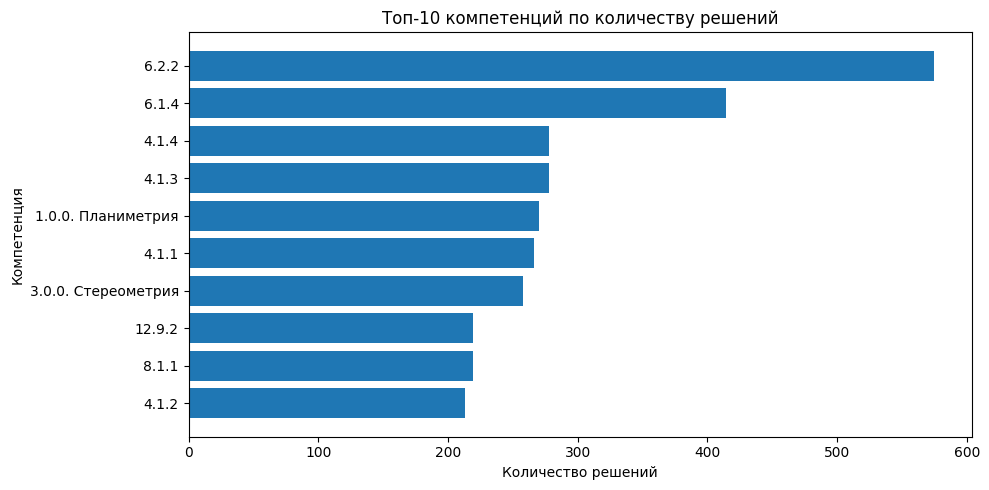

In [ ]:
top = competence_summary.head(10).copy()

plt.figure(figsize=(10, 5))
plt.barh(top['competence_code'][::-1], top['solved_tasks_count'][::-1])
plt.title('Топ-10 компетенций по количеству решений')
plt.xlabel('Количество решений')
plt.ylabel('Компетенция')
plt.tight_layout()
plt.show()

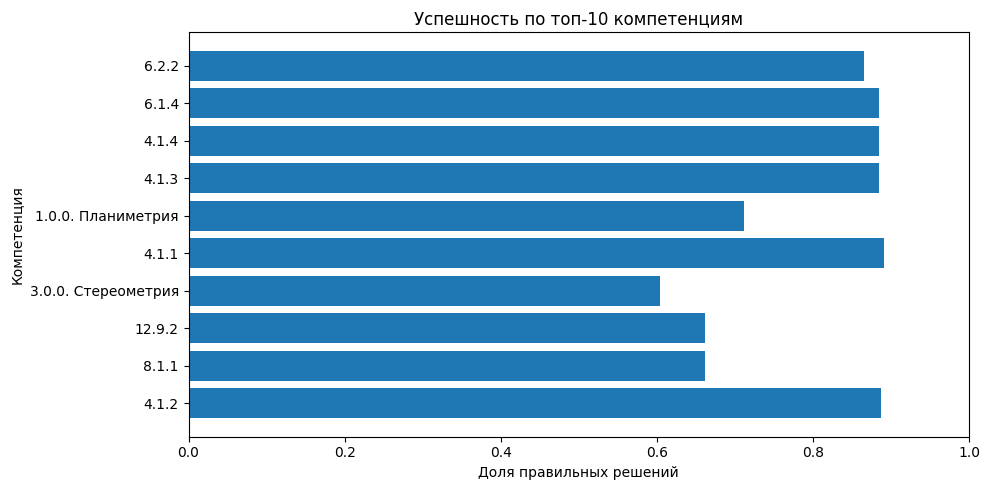

In [ ]:
top = competence_summary.head(10).copy()

plt.figure(figsize=(10, 5))
plt.barh(top['competence_code'][::-1], top['accuracy'][::-1])
plt.title('Успешность по топ-10 компетенциям')
plt.xlabel('Доля правильных решений')
plt.ylabel('Компетенция')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Для каждого решённого задания подтянул связанные с ним компетенции, после чего собрал итоговую таблицу на уровне ученик × компетенция.

В итоговой таблице для каждой пары ученик-компетенция посчитаны:
- количество решённых заданий по компетенции;
- количество правильно решённых заданий;
- доля правильных решений;
- дата первого решения по компетенции;
- дата последнего решения по компетенции;
- количество дней между первым и последним решением.

Также построил два графика:
- топ компетенций по количеству решений;
- успешность по наиболее часто встречающимся компетенциям.

Отдельно проверил качество маппинга заданий на компетенции: часть решений не попала в анализ, потому что для них отсутствует связь task_id -> competence_id, таких строк 564.

Результат - в файле student_competence_readiness.csv, можно использовать как таблицу признаков нарешанности ученика по компетенциям для дальнейшей работы с рекомендательной системой.